In [2]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("../data/20220519_full_mm_gsadk_sdm-1.csv", header=0)

In [4]:
df.head()

,Time [s],Temp. [°C],E1,E2,E3,E4,E5,E6,E7,E8,...,J7,J8,J9,J10,J11,J12,J13,J14,J15,J16
0,0.000,28.7,8949,8905,4657,5286,3665,3320,2898,2503,...,2669,2894,2160,2266,2207,2020,1848,1978,1871,1927
1,65.403,28.6,8812,8714,4534,4977,3458,3189,2793,2487,...,2625,2625,2179,2225,2176,2003,1834,1976,1798,1937
2,130.315,28.5,10990,8623,4486,5012,3441,3172,2705,2445,...,2610,2637,2148,2217,2160,2017,1858,1962,1801,1917
3,195.222,28.5,10716,8684,4564,4966,3502,3174,2688,2447,...,2571,2677,2195,2257,2185,2015,1871,1976,1799,1928
4,260.134,28.5,10289,8625,4538,4931,3409,3195,2709,2418,...,2585,2667,2157,2234,2198,2039,1874,1969,1806,1887


In [5]:
gs_wt_df = df.iloc[:, 70:86].T
gs_wt_df

,0,1,2,3,4,5,6,7,8,9,...,212,213,214,215,216,217,218,219,220,221
I1,9083,9023,9153,9274,9661,9669,9932,10106,10253,10400,...,33652,34103,34096,34315,34488,35055,34266,34077,34697,34728
I2,8401,8388,8637,8701,8880,8939,9227,9417,9669,9810,...,31903,32040,32244,32137,32302,33408,32354,32356,32779,33076
I3,5470,5541,5800,5920,6232,6358,6614,6862,7192,7264,...,30322,30195,30301,30280,30847,30983,30639,30391,30593,31514
I4,5032,5043,5299,5550,5745,5864,6074,6347,6501,6778,...,28970,29294,29405,29264,29589,30059,29211,29613,29414,30037
I5,3789,3917,4087,4287,4443,4600,4767,4958,5152,5261,...,24313,24596,24638,24647,25226,25392,24786,24740,25057,25405
I6,3900,3987,4425,4446,4637,4777,4936,5040,5124,5330,...,24338,24433,24892,24525,24637,25002,24571,24806,24793,25418
I7,3011,3070,3194,3333,3443,3535,3692,3791,3891,4038,...,18587,18818,18648,18610,19017,18932,18832,18648,18905,19222
I8,2872,3011,3067,3260,3394,3549,3658,3829,3910,4100,...,19569,19542,19548,19705,20050,19856,19650,19818,19875,20101
I9,2742,2838,2850,2929,3036,3089,3192,3278,3301,3439,...,14406,14475,14603,14606,14746,14791,14790,14750,14641,14968
I10,2612,2566,2650,2731,2800,2853,2912,2986,3075,3100,...,13527,13775,13834,13830,13867,13953,13877,13766,13862,14036


In [6]:
times = np.tile(df["Time [s]"], (16,1))

In [7]:
times

array([[    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       ...,
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305]])

In [17]:
time_arr = times[0]

In [8]:
gs_wt_arr = np.array(gs_wt_df)

Text(0, 0.5, 'RFU')

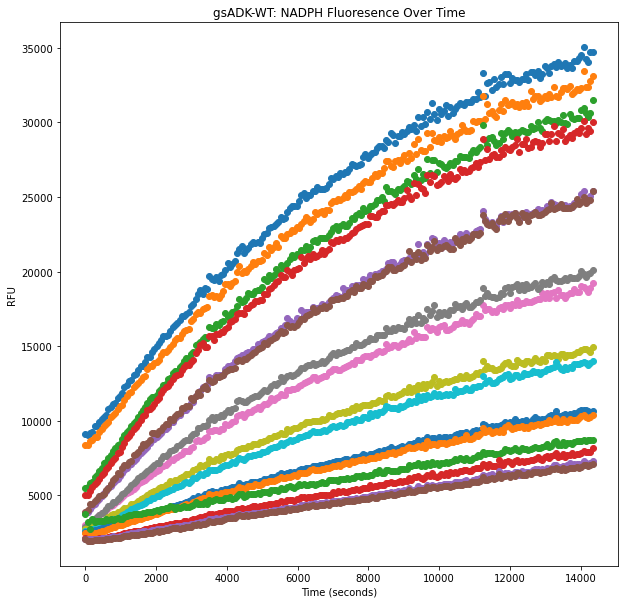

In [10]:
fig = plt.figure(figsize=(10,10))
for rfu, time in zip(gs_wt_arr, times):
    plt.scatter(time, rfu)
    
plt.title("gsADK-WT: NADPH Fluoresence Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("RFU")

## Get Initial Rate

## Trying "Gradient Descent Approach" To Initial Rate

In [11]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

## Wrapping Initial Slope into a Function

In [103]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    for i in range(len(perc_times), min_included_percent, -1):
        curr_times = [item for sublist in perc_times[:i] for item in sublist]
        curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    max_r2_idx = np.argmax(scores)
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]

# Applying New Function to gsADK WT Data

In [13]:
sub_concs = [1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

In [23]:
gs_wt_arr_rep_1 = gs_wt_arr[0::2] / 179
gs_wt_arr_rep_2 = gs_wt_arr[1::2] / 179

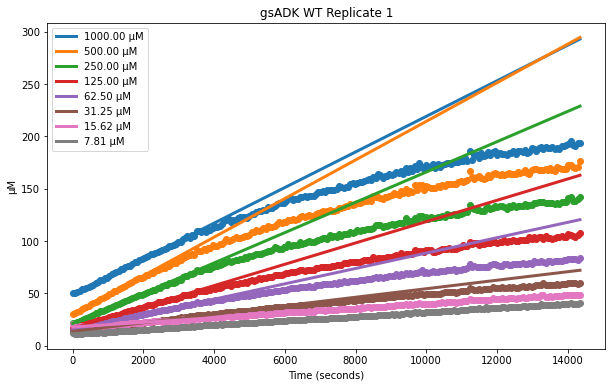

In [115]:
fig = plt.figure(figsize=(10,6))
    
for rep, sub_conc in zip(gs_wt_arr_rep_1, sub_concs):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("gsADK WT Replicate 1")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

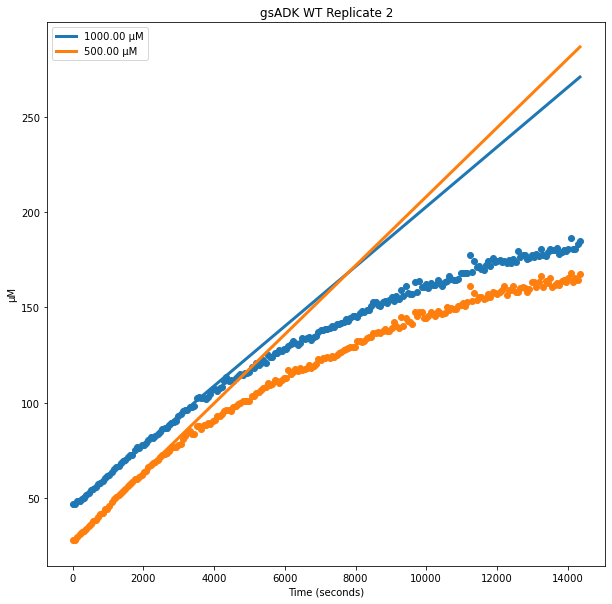

In [75]:
fig = plt.figure(figsize=(10,10))
    
for rep, sub_conc in list(zip(gs_wt_arr_rep_2, sub_concs))[:2]:
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("gsADK WT Replicate 2")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

# Micheaelis Menten for bsADK

In [19]:
gs_adk_rep_1_slopes = []
gs_adk_rep_2_slopes = []

for rep, sub_conc in zip(gs_wt_arr[0::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    gs_adk_rep_1_slopes.append(slope)

for rep, sub_conc in zip(gs_wt_arr[1::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    gs_adk_rep_2_slopes.append(slope)

In [20]:
gs_adk_avg_slopes = np.mean([gs_adk_rep_1_slopes, gs_adk_rep_2_slopes], axis=0)
errs = np.std([gs_adk_rep_1_slopes, gs_adk_rep_2_slopes], axis=0)

In [21]:
e_conc = .652 * 1e-4

Text(0, 0.5, 'v (µM/s)')

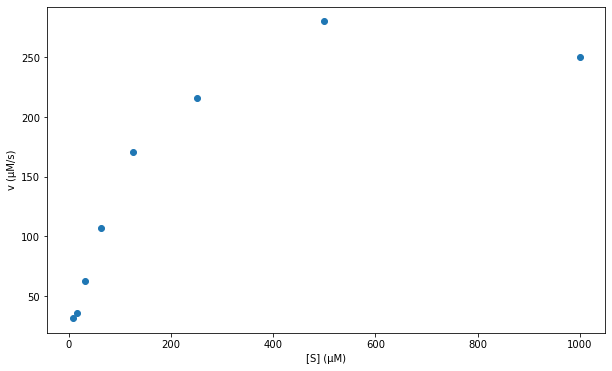

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(sub_concs, np.array(gs_adk_avg_slopes) / e_conc)
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")

In [27]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [28]:
from scipy.optimize import curve_fit

In [29]:
params, _ = curve_fit(mm_model, sub_concs, np.concatenate(gs_adk_avg_slopes))

In [64]:
errs / e_conc

array([[10.2544241 ],
       [ 2.83066606],
       [ 6.60964142],
       [14.24638087],
       [ 5.46051258],
       [ 0.57572034],
       [ 1.6668316 ],
       [ 0.10209961]])

In [60]:
np.concatenate(gs_adk_avg_slopes/e_conc)

array([250.62136791, 280.15060235, 215.5864495 , 170.58722999,
       107.24584295,  62.97780938,  35.68189469,  31.63919855])

Text(0.5, 1.0, 'SNAP gsADK WT MM kinetics: $k_{cat}$ = 303 $s^{-1}$   $K_m$ = 102 µM')

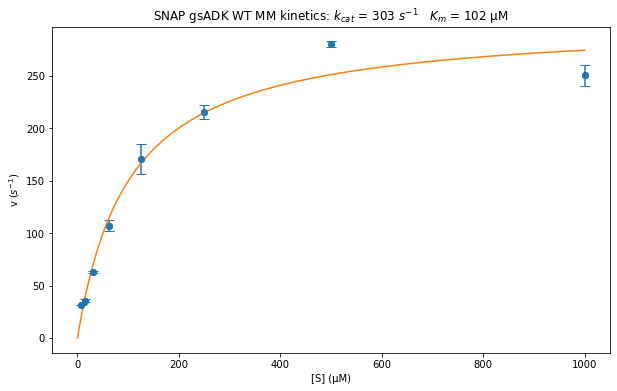

In [70]:
plt.figure(figsize=(10,6))

plt.scatter(sub_concs, gs_adk_avg_slopes/e_conc)
plt.errorbar(sub_concs, np.concatenate(gs_adk_avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
x = np.linspace(0, 1000, 1000)
plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
plt.xlabel("[S] (µM)")
plt.ylabel("v ($s^{-1}$)")
plt.title("SNAP gsADK WT MM kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} µM")

# gsADK I111L Plotting

In [81]:
gs_i111l_df = df.iloc[:, 19:35]
gs_i111l_arr = np.array(gs_i111l_df).T

Text(0, 0.5, 'RFU')

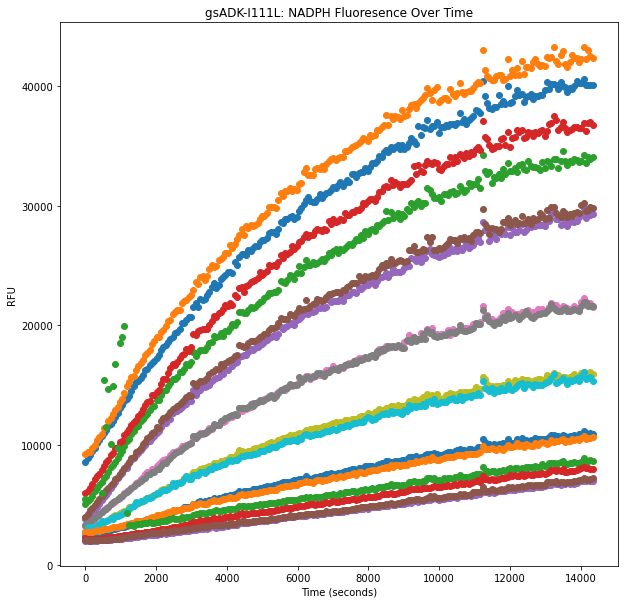

In [82]:
fig = plt.figure(figsize=(10,10))
for rfu, time in zip(gs_i111l_arr, times):
    plt.scatter(time, rfu)
    
plt.title("gsADK-I111L: NADPH Fluoresence Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("RFU")

In [84]:
gs_i111l_arr_rep_1 = gs_i111l_arr[0::2] / 179
gs_i111l_arr_rep_2 = gs_i111l_arr[1::2] / 179

[0.1272148532872064, 0.11919535293631855, 0.11093944582784143, 0.1034198646629011, 0.09613052626024932, 0.08836825758937883, 0.08072710728023524, 0.0732918273312585, 0.06649316282334894, 0.0602341224399876, 0.05378777086646924, 0.047847952929433, 0.041805245698532834, 0.03614857113552983, 0.031068287633742697, 0.026277091807454966, 0.02172877778344917, 0.017297181898613512, 0.013839369073931351, 0.010917735494816228, 0.00810549075326028, 0.00580840764020496, 0.0038516923540753423, 0.0024260403272023945, 0.0011009964716222065, 0.0003153514766982557, 1.0937735526961312e-05, 0.00015087865091234498, 0.0006455712621138421, 0.0015123914949430883, 0.002865765300915535, 0.004643973561971992, 0.006686989392546305, 0.009159661508185368, 0.012016402329952935, 0.01500250729039565, 0.018442737389690822, 0.022219662774296323, 0.026025011419320343, 0.030162748757589175, 0.034402120071548414, 0.03892958503234489, 0.04410420079955668, 0.04941353165218876, 0.054484970405034194, 0.05981965068564721, 0.06

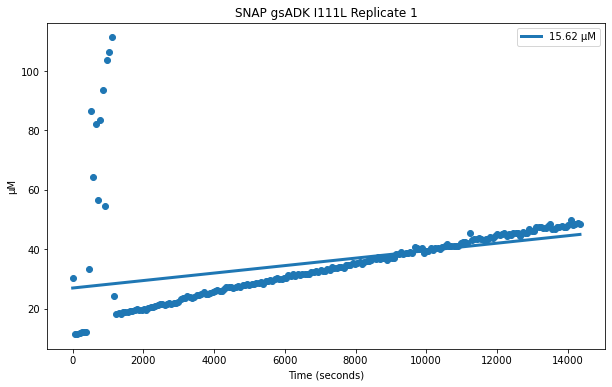

In [101]:
fig = plt.figure(figsize=(10,6))
    
for rep, sub_conc in list(zip(gs_i111l_arr_rep_1, sub_concs))[6:7]:
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep, min_included_percent=7)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("SNAP gsADK I111L Replicate 1")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

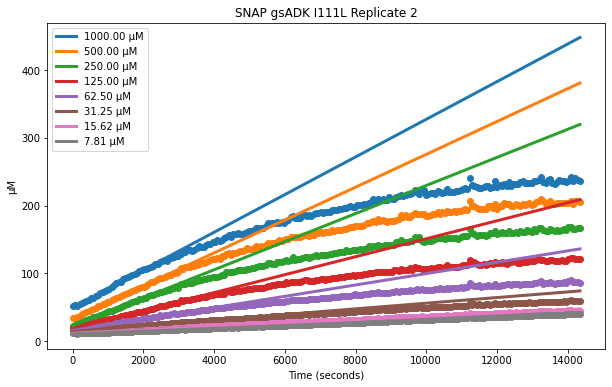

In [93]:
fig = plt.figure(figsize=(10,6))
    
for rep, sub_conc in zip(gs_i111l_arr_rep_2, sub_concs):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("SNAP gsADK I111L Replicate 2")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

In [104]:
gs_adk_i111l_rep_1_slopes = []
gs_adk_i111l_rep_2_slopes = []

for rep, sub_conc in zip(gs_i111l_arr[0::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    gs_adk_i111l_rep_1_slopes.append(slope)

for rep, sub_conc in zip(gs_i111l_arr[1::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    gs_adk_i111l_rep_2_slopes.append(slope)

In [107]:
gs_adk_i111l_rep_1_slopes[6] = gs_adk_i111l_rep_2_slopes[6]

In [108]:
gs_adk_i111l_avg_slopes = np.mean([gs_adk_i111l_rep_1_slopes, gs_adk_i111l_rep_2_slopes], axis=0)
i111l_errs = np.std([gs_adk_i111l_rep_1_slopes, gs_adk_i111l_rep_2_slopes], axis=0)

In [109]:
gs_i111l_conc = .618 * 1e-4

In [111]:
i111l_params, _ = curve_fit(mm_model, sub_concs, np.concatenate(gs_adk_i111l_avg_slopes))

Text(0.5, 1.0, 'SNAP gsADK I111L MM kinetics: $k_{cat}$ = 513 $s^{-1}$   $K_m$ = 155 µM')

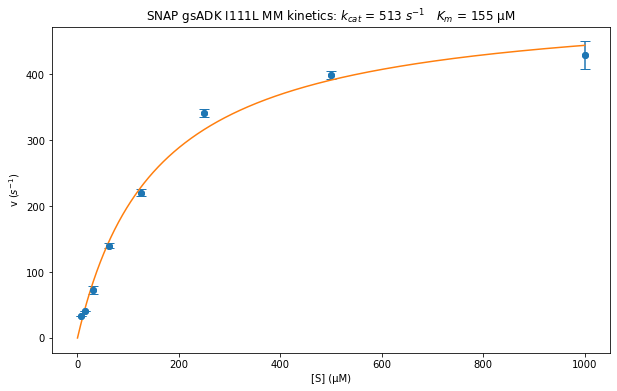

In [114]:
plt.figure(figsize=(10,6))

plt.scatter(sub_concs, gs_adk_i111l_avg_slopes/gs_i111l_conc)
plt.errorbar(sub_concs, np.concatenate(gs_adk_i111l_avg_slopes/gs_i111l_conc), yerr=(i111l_errs/gs_i111l_conc).T, fmt="o", capsize=5)
x = np.linspace(0, 1000, 1000)
plt.plot(x, mm_model(x, i111l_params[0], i111l_params[1]) / gs_i111l_conc)
plt.xlabel("[S] (µM)")
plt.ylabel("v ($s^{-1}$)")
plt.title("SNAP gsADK I111L MM kinetics: $k_{cat}$ = " +f"{i111l_params[0] / gs_i111l_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {i111l_params[1]:.0f} µM")